In [ ]:
#Installation of necessary packages and download the data
!pip install simpeg discretize pymatsolver
# Download and correctly copy the century data and images
!rm -rf transform-2020-simpeg
!rm -rf century
!git clone --depth 1 --filter=blob:none --sparse https://github.com/simpeg/transform-2020-simpeg.git
!cd transform-2020-simpeg && git sparse-checkout set century images

# Create local directories
!mkdir -p century
!mkdir -p images

# Clean up any existing data and copy new files
!cp -r transform-2020-simpeg/century/. century/

# Copy the contents of the images folder from the repo to the local images folder
!cp -r transform-2020-simpeg/images/. images/

# Verify the contents and clean up the cloned repo
!ls -la images/
!rm -rf transform-2020-simpeg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.9/513.9 kB 9.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 13.8 MB/s eta 0:00:00
  Created wheel for simpeg: filename=simpeg-0.25.2-py3-none-any.whl size=595275 sha256=a1479728eea9e70f804dad5b989eaa188ee7531bccbbec396b5c3b89525f1b9e
  Stored in directory: /root/.cache/pip/wheels/8a/db/6f/b6da5be3c64674bd3af27db599ff3f633a39e325b67485a2f1
  Created wheel for pymatsolver: filename=pymatsolver-0.4.0-py3-none-any.whl size=15857 sha256=b52832c99f37049ef1ad398ae355ff0cc30a0c3502c1b60056cf0b9d

In [ ]:
# Imports of necessary libraries and modules for the script
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
from matplotlib.colors import LogNorm, SymLogNorm, Normalize
import ipywidgets

import discretize

# Fallback to SolverLU if Pardiso/pydiso is not available
try:
    from pymatsolver import Pardiso as Solver
    # Test if it actually works
    import pydiso
except (ImportError, ModuleNotFoundError):
    from simpeg import SolverLU as Solver

from simpeg import (
    maps,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
)
from simpeg.data import Data
from simpeg.electromagnetics import resistivity as dc
from simpeg.electromagnetics import induced_polarization as ip
from simpeg.electromagnetics.static import utils as static_utils

warnings.filterwarnings("ignore")
rcParams["font.size"] = 14

# ERTH3250: Data Visualization and Inversion of DC & IP data from synthetic model

 (Originally from: https://github.com/simpeg/transform-2020-simpeg. simpeg: Simulation and Parameter Estimation in Geophysics, http://simpeg.xyz, developed by The University of British Columbia)

The visualized data is from Century Deposit, which is a Zinc-lead-silver deposit is located 250 km to the NNW of the Mt Isa region in Queensland Australia (Location: 18° 43' 15"S, 138° 35' 54"E).

<img src="https://github.com/simpeg/transform-2020-simpeg/blob/main/images/Mutton-Figure1-1.png?raw=1" width=45%>

<img src="https://github.com/simpeg/transform-2020-simpeg/blob/main/images/Mutton-Figure2-1.png?raw=1" width=70%>

**References**
- [Mutton (2000)](https://doi.org/10.1190/1.1444878)

- [geologic background](http://www.portergeo.com.au/database/mineinfo.asp?mineid=mn075)

For background on DC Resistivity Surveys, see [GPG: DC Resistivity](https://gpg.geosci.xyz/content/DC_resistivity/index.html)

In this notebook, we are going to visualize the data first.
And then according to the python functions defined already, to construct synthetic models and run the inversions using AI/LLM for code writing. First is ERT/DC synthetic model and then using AI to code for IP synthetic model case.

## 1: Visualize the data


**What are our data?**

The survey collected at the Century Deposit uses a dipole-dipole geometry with:
- Current Electrodes (A, B): we refer to the source electrodes as "A" for the positive electrode and "B" for the negative electrode.
- Potential Electrodes (M, N): we refer to the positive potential electrode as "M" and the negative as "N".

A datum is the potential difference between the M and N electrodes.

<img src="https://gpg.geosci.xyz/_images/add1.gif">

<img src="https://gpg.geosci.xyz/_images/add2.gif">

In [ ]:
# Python Function definitions

def read_dcip_data(filename, verbose=True):
    """Read a UBC-GIF .OBS DC/IP file into a dictionary."""
    contents = np.genfromtxt(filename, delimiter=' \n', dtype=str)
    n_sources = int(contents[1].split()[0])

    if verbose:
        print(f"number of sources: {n_sources}")

    a_locations = np.zeros(n_sources)
    b_locations = np.zeros(n_sources)
    m_locations, n_locations = [], []
    observed_data, standard_deviations = [], []

    content_index = 1
    for i in range(n_sources):
        content_index += 1
        a_location, b_location, nrx = contents[content_index].split()

        a_locations[i] = float(a_location)
        b_locations[i] = float(b_location)
        nrx = int(nrx)

        if verbose:
            print(
                f"Source {i}: A-loc: {a_location}, B-loc: {b_location}, N receivers: {nrx}"
            )

        m_locations_i = np.zeros(nrx)
        n_locations_i = np.zeros(nrx)
        observed_data_i = np.zeros(nrx)
        standard_deviations_i = np.zeros(nrx)

        for j in range(nrx):
            content_index += 1
            m_location, n_location, datum, std = contents[content_index].split()
            m_locations_i[j] = float(m_location)
            n_locations_i[j] = float(n_location)
            observed_data_i[j] = float(datum)
            standard_deviations_i[j] = float(std)

        m_locations.append(m_locations_i)
        n_locations.append(n_locations_i)
        observed_data.append(observed_data_i)
        standard_deviations.append(standard_deviations_i)

    return {
        "a_locations": a_locations,
        "b_locations": b_locations,
        "m_locations": m_locations,
        "n_locations": n_locations,
        "observed_data": observed_data,
        "standard_deviations": standard_deviations,
        "n_sources": n_sources,
    }


def build_dipole_survey(data_dict, em_module, data_type=None, x_shift=0.0):
    """Construct a dipole-dipole survey for DC or IP from parsed data."""
    src_list = []
    for i in range(data_dict["n_sources"]):
        m_locs = np.vstack([
            data_dict["m_locations"][i] - x_shift,
            np.zeros_like(data_dict["m_locations"][i]),
        ]).T

        n_locs = np.vstack([
            data_dict["n_locations"][i] - x_shift,
            np.zeros_like(data_dict["n_locations"][i]),
        ]).T

        if data_type is None:
            receivers = em_module.receivers.Dipole(
                locations_m=m_locs, locations_n=n_locs, storeProjections=False
            )
        else:
            receivers = em_module.receivers.Dipole(
                locations_m=m_locs,
                locations_n=n_locs,
                data_type=data_type,
                storeProjections=False,
            )

        source = em_module.sources.Dipole(
            location_a=np.r_[data_dict["a_locations"][i] - x_shift, 0.0],
            location_b=np.r_[data_dict["b_locations"][i] - x_shift, 0.0],
            receiver_list=[receivers],
        )
        src_list.append(source)

    return em_module.Survey(src_list)


def build_mesh(
    survey,
    n_cells_per_spacing_x=4,
    n_cells_per_spacing_z=4,
    n_core_extra_x=4,
    n_core_extra_z=4,
    core_domain_z_ratio=1 / 3.0,
    padding_factor=1.3,
    n_pad_x=10,
    n_pad_z=10,
):
    """Design a 2D tensor mesh based on survey geometry."""
    min_electrode_spacing = np.min(np.abs(survey.locations_a[:, 0] - survey.locations_b[:, 0]))

    dx = min_electrode_spacing / n_cells_per_spacing_x
    dz = min_electrode_spacing / n_cells_per_spacing_z

    core_domain_x = np.r_[
        survey.unique_electrode_locations[:, 0].min(),
        survey.unique_electrode_locations[:, 0].max(),
    ]

    mid_ab = (survey.locations_a + survey.locations_b) / 2
    mid_mn = (survey.locations_m + survey.locations_n) / 2
    separation_ab_mn = np.abs(mid_ab - mid_mn)
    max_separation = separation_ab_mn.max()
    core_domain_z = np.r_[-core_domain_z_ratio * max_separation, 0.0]

    n_core_x = int(np.ceil(np.diff(core_domain_x)[0] / dx) + n_core_extra_x * 2)
    n_core_z = int(np.ceil(np.diff(core_domain_z)[0] / dz) + n_core_extra_z)

    hx = [
        (dx, n_pad_x, -padding_factor),
        (dx, n_core_x),
        (dx, n_pad_x, padding_factor),
    ]
    hz = [(dz, n_pad_z, -padding_factor), (dz, n_core_z)]

    mesh = discretize.TensorMesh([hx, hz], x0="CN")
    return mesh, core_domain_x, core_domain_z


def get_mesh_display_limits(survey):
    """Return a fixed survey-based window for displaying mesh layouts."""
    electrode_x = survey.unique_electrode_locations[:, 0]
    x_center = 0.5 * (electrode_x.min() + electrode_x.max())
    x_span = electrode_x.max() - electrode_x.min()

    mid_ab = (survey.locations_a + survey.locations_b) / 2
    mid_mn = (survey.locations_m + survey.locations_n) / 2
    max_separation = np.abs(mid_ab - mid_mn)[:, 0].max()

    x_half_width = 0.5 * x_span + 1.25 * max_separation
    z_limits = np.r_[-1.6 * max_separation, 0.15 * max_separation]
    x_limits = np.r_[x_center - x_half_width, x_center + x_half_width]
    return x_limits, z_limits


def forward_simulation_halfspace(mesh, survey, resistivity=100, nky=11):
    """Forward simulate a half-space model and return data."""
    for src in survey.source_list:
        src._q = None

    rho = resistivity * np.ones(mesh.nC)
    simulation_dc = dc.Simulation2DNodal(
        mesh,
        rhoMap=maps.IdentityMap(mesh),
        solver=Solver,
        survey=survey,
        nky=nky,
    )
    dpred = simulation_dc.make_synthetic_data(rho)

    for src in survey.source_list:
        src._q = None

    return dpred


def plot_apparent_resistivities(
    dpred,
    survey,
    halfspace_resistivity,
    line_name="line",
    mesh=None,
    core_domain_x=None,
    core_domain_z=None,
):
    """Plot pseudosection, error, and an optional mesh panel."""
    if mesh is None:
        fig = plt.figure(constrained_layout=True, figsize=(12, 4))
        gs = fig.add_gridspec(ncols=3, nrows=1)
        ax0 = fig.add_subplot(gs[:2])
        ax1 = fig.add_subplot(gs[2])
        ax_mesh = None
    else:
        fig = plt.figure(constrained_layout=True, figsize=(12, 8.2))
        gs = fig.add_gridspec(ncols=3, nrows=2, height_ratios=[1.0, 2.35])
        ax0 = fig.add_subplot(gs[0, :2])
        ax1 = fig.add_subplot(gs[0, 2])
        ax_mesh = fig.add_subplot(gs[1, :])

    static_utils.plot_pseudosection(
        dpred,
        data_type="apparent resistivity",
        plot_type="pcolor",
        data_locations=True,
        ax=ax0,
        pcolor_opts={},
    )
    ax0.set_aspect(1.5)
    ax0.set_title(f"{line_name} Pseudosection", pad=8)
    ax0.set_xlabel("Northing (m)")
    ax0.set_yticks([])

    mid_ab = (survey.locations_a + survey.locations_b) / 2
    mid_mn = (survey.locations_m + survey.locations_n) / 2
    separation_ab_mn = np.abs(mid_ab - mid_mn)
    apparent_resistivity = static_utils.apparent_resistivity_from_voltage(survey, dpred.dobs)
    percent_error = (apparent_resistivity - halfspace_resistivity) / halfspace_resistivity * 100

    ax1.plot(separation_ab_mn[:, 0], percent_error, ".", alpha=0.4)
    ax1.set_xlabel("AB - MN separation")
    ax1.set_ylabel("percent difference (%)")
    ax1.set_title("Error in apparent resistivities", pad=8)
    ax1.grid(alpha=0.3)
    ax1.margins(x=0.08, y=0.15)

    if ax_mesh is not None:
        mesh_xlim, mesh_ylim = get_mesh_display_limits(survey)
        mesh.plot_grid(ax=ax_mesh)
        ax_mesh.set_xlim(mesh_xlim)
        ax_mesh.set_ylim(mesh_ylim)
        ax_mesh.plot(
            survey.unique_electrode_locations[:, 0],
            survey.unique_electrode_locations[:, 1],
            ".",
            color="0.4",
            ms=4,
        )
        ax_mesh.set_title("Mesh Layout")
        ax_mesh.set_xlabel("Northing (m)")
        ax_mesh.set_ylabel("Elevation (m)")
        ax_mesh.set_aspect(1.5)


def mesh_design_simulator(
    survey,
    line_name="line",
    n_cells_per_spacing_x=4,
    n_cells_per_spacing_z=4,
    n_core_extra_x=4,
    n_core_extra_z=4,
    core_domain_z_ratio=1 / 3.0,
    padding_factor=1.3,
    n_pad_x=10,
    n_pad_z=10,
    log10_halfspace_resistivity=2,
    nky=11,
):
    """Interactive driver that links mesh parameters to forward-model error plots."""
    mesh, core_domain_x, core_domain_z = build_mesh(
        survey=survey,
        n_cells_per_spacing_x=n_cells_per_spacing_x,
        n_cells_per_spacing_z=n_cells_per_spacing_z,
        n_core_extra_x=n_core_extra_x,
        n_core_extra_z=n_core_extra_z,
        core_domain_z_ratio=core_domain_z_ratio,
        padding_factor=padding_factor,
        n_pad_x=n_pad_x,
        n_pad_z=n_pad_z,
    )

    halfspace_resistivity = 10 ** log10_halfspace_resistivity
    dpred = forward_simulation_halfspace(mesh, survey=survey, resistivity=halfspace_resistivity, nky=nky)
    plot_apparent_resistivities(
        dpred,
        survey=survey,
        halfspace_resistivity=halfspace_resistivity,
        line_name=line_name,
        mesh=mesh,
        core_domain_x=core_domain_x,
        core_domain_z=core_domain_z,
    )


def plot_building_pseudosection(dc_data, dc_data_dict, source_ind=0, xlim=None):
    """Visualize how pseudosection points are constructed for one source."""
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    pseudo_locs = static_utils.pseudo_locations(dc_data.survey)
    mid_x, mid_z = pseudo_locs[:, 0], pseudo_locs[:, 1]
    ax.plot(mid_x, mid_z, ".k", alpha=0.5)

    electrode_positions = np.unique(
        np.r_[
            dc_data_dict["a_locations"],
            dc_data_dict["b_locations"],
            np.hstack(dc_data_dict["m_locations"]),
            np.hstack(dc_data_dict["n_locations"]),
        ]
    )
    ax.plot(
        electrode_positions,
        np.zeros_like(electrode_positions),
        ".",
        color="0.7",
        ms=10,
        zorder=1,
    )

    a_loc = dc_data_dict["a_locations"][source_ind]
    b_loc = dc_data_dict["b_locations"][source_ind]
    src_mid = (a_loc + b_loc) / 2
    ax.plot(np.r_[a_loc, b_loc], np.r_[0, 0], "C0.")
    ax.plot(src_mid, np.r_[0], "C0x", ms=6)

    m_locs = dc_data_dict["m_locations"][source_ind]
    n_locs = dc_data_dict["n_locations"][source_ind]
    rx_mid = (m_locs + n_locs) / 2
    ax.plot(np.r_[m_locs, n_locs], np.zeros(2 * len(m_locs)), "C1.")
    ax.plot(rx_mid, np.zeros_like(m_locs), "C1x", ms=6)

    pseudo_x = (rx_mid + src_mid) / 2
    pseudo_z = -np.abs(rx_mid - src_mid) / 2

    ax.plot(np.r_[src_mid, pseudo_x], np.r_[0, pseudo_z], "-k", alpha=0.3)
    for rx_x, px, pz in zip(rx_mid, pseudo_x, pseudo_z):
        ax.plot(np.r_[px, rx_x], np.r_[pz, 0], "-k", alpha=0.3)

    ax.plot(pseudo_x, pseudo_z, "C2o")
    ax.set_xlabel("Northing (m)")
    ax.set_ylabel("n-spacing")
    ax.set_yticklabels([])
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.set_aspect(1.5)


def plot_physics(
    field,
    primsec,
    scale,
    source_ind,
    survey,
    mesh,
    rho,
    model_background,
    fields,
    fields_background,
    core_domain_x,
    core_domain_z,
):
    """Plot the selected physical quantity for a single source on the synthetic mesh."""
    fig, ax = plt.subplots(1, 1, figsize=(12, 4.8))

    pcolor_opts = {}
    view = "real"
    v_type = "CC"
    source = survey.source_list[source_ind]

    if field == "model":
        plotme = rho.copy()
        if primsec == "primary":
            plotme = model_background.copy()
        elif primsec == "secondary":
            plotme = plotme - model_background
        if scale.lower() == "log":
            pcolor_opts["norm"] = LogNorm()
    else:
        if primsec in ["total", "secondary"]:
            plotme = fields[source, field].copy()
            if primsec == "secondary":
                plotme = plotme - fields_background[source, field]
        else:
            plotme = fields_background[source, field].copy()

        if field == "phi":
            plotme = mesh.aveN2CC * plotme
        elif field in ["j", "e"]:
            view = "vec"
            v_type = "CCv"
            plotme = mesh.aveE2CCV * plotme
            if scale.lower() == "log":
                pcolor_opts["norm"] = LogNorm()
        elif field == "charge_density":
            pcolor_opts["cmap"] = "RdBu_r"

        if field in ["phi", "charge_density"]:
            max_abs = np.abs(plotme).max()
            if scale.lower() == "linear":
                pcolor_opts["norm"] = Normalize(vmin=-max_abs, vmax=max_abs)
            else:
                pcolor_opts["norm"] = SymLogNorm(
                    linthresh=max_abs * 1e-3, vmin=-max_abs, vmax=max_abs
                )

    out = mesh.plot_image(
        plotme,
        view=view,
        v_type=v_type,
        pcolor_opts=pcolor_opts,
        ax=ax,
        range_x=core_domain_x,
        range_y=core_domain_z,
    )
    ax.plot([source.location_a[0], source.location_b[0]], np.r_[5, 5], "vC3", ms=8)
    ax.set_xlim(core_domain_x)
    ax.set_ylim(core_domain_z + np.r_[-100, 0])
    ax.set_aspect(1.5)
    ax.set_xlabel("Northing (m)")
    ax.set_ylabel("Elevation (m)")
    ax.set_title(f"{field} ({primsec}, {scale})")
    plt.colorbar(out[0], ax=ax, label=field, fraction=0.08, orientation="horizontal", pad=0.2)
    plt.tight_layout()


class SaveInversionProgress(directives.InversionDirective):
    """Save inversion diagnostics at each iteration."""

    def initialize(self):
        """Initialize storage containers before the first inversion iteration."""
        self.inversion_results = {
            "iteration": [],
            "beta": [],
            "phi_d": [],
            "phi_m": [],
            "phi_m_small": [],
            "phi_m_smooth_x": [],
            "phi_m_smooth_z": [],
            "dpred": [],
            "model": [],
        }

    def endIter(self):
        """Record objective terms, predictions, and model state after each iteration."""
        self.inversion_results["iteration"].append(self.opt.iter)
        self.inversion_results["beta"].append(self.invProb.beta)
        self.inversion_results["phi_d"].append(self.invProb.phi_d)
        self.inversion_results["phi_m"].append(self.invProb.phi_m)
        self.inversion_results["dpred"].append(self.invProb.dpred)
        self.inversion_results["model"].append(self.invProb.model)

        reg = self.reg.objfcts[0]
        phi_s = reg.objfcts[0](self.invProb.model) * reg.multipliers[0]
        phi_x = reg.objfcts[1](self.invProb.model) * reg.multipliers[1]
        phi_z = reg.objfcts[2](self.invProb.model) * reg.multipliers[2]
        self.inversion_results["phi_m_small"].append(phi_s)
        self.inversion_results["phi_m_smooth_x"].append(phi_x)
        self.inversion_results["phi_m_smooth_z"].append(phi_z)


def create_inverse_problem(
    synthetic_data,
    simulation_dc,
    mesh,
    rho_background,
    relative_error=0.05,
    noise_floor=1e-4,
    alpha_s=1e-3,
    alpha_x=1.0,
    alpha_z=1.0,
    mref=None,
    maxIter=20,
    maxIterCG=20,
):
    """Create and return a SimPEG inverse problem object from data, simulation, and settings."""
    if mref is None:
        mref = np.log(rho_background)

    synthetic_data.relative_error = relative_error
    synthetic_data.noise_floor = noise_floor
    dmisfit = data_misfit.L2DataMisfit(data=synthetic_data, simulation=simulation_dc)

    reg = regularization.WeightedLeastSquares(
        mesh,
        alpha_s=alpha_s,
        alpha_x=alpha_x,
        alpha_y=alpha_z,
        reference_model=mref * np.ones(mesh.nC),
    )

    opt = optimization.InexactGaussNewton(maxIter=maxIter, maxIterCG=maxIterCG)
    opt.remember("xc")
    return inverse_problem.BaseInvProblem(dmisfit, reg, opt)


def create_inversion(
    inv_prob,
    beta0_ratio=1e2,
    cool_beta=True,
    beta_cooling_factor=2,
    beta_cooling_rate=1,
    use_target=True,
    chi_factor=1,
):
    """Create inversion directives and return inversion object plus helper directives."""
    beta_est = directives.BetaEstimate_ByEig(beta0_ratio=beta0_ratio)
    target = directives.TargetMisfit(chifact=chi_factor)
    save = SaveInversionProgress()

    directives_list = [beta_est, save]
    if use_target:
        directives_list.append(target)
    if cool_beta:
        beta_schedule = directives.BetaSchedule(
            coolingFactor=beta_cooling_factor, coolingRate=beta_cooling_rate
        )
        directives_list.append(beta_schedule)

    return inversion.BaseInversion(inv_prob, directiveList=directives_list), target, save


def plot_normalized_misfit(inversion_results, observed_data, iteration=None, ax=None):
    """Plot |d_pred - d_obs| / std as a pseudosection for a chosen iteration."""
    if ax is None:
        _, ax = plt.subplots(1, 1)

    dpred = inversion_results["dpred"][-1] if iteration is None else inversion_results["dpred"][iteration]
    normalized_misfit = np.abs(dpred - observed_data.dobs) / observed_data.standard_deviation

    static_utils.plot_pseudosection(
        observed_data,
        dobs=normalized_misfit,
        data_type="misfit",
        plot_type="contourf",
        data_locations=True,
        ax=ax,
        cbar_opts={"pad": 0.25},
        contourf_opts={},
    )

    ax.set_title("normalized misfit")
    ax.set_yticklabels([])
    ax.set_aspect(1.5)
    ax.set_xlabel("Northing (m)")
    ax.set_ylabel("n-spacing")
    cb_axes = plt.gcf().get_axes()[-1]
    cb_axes.set_xlabel("normalized misfit")
    return ax


def plot_beta(inversion_results, x="iteration", ax=None):
    """Plot beta schedule versus iteration (or versus another x-axis key)."""
    if ax is None:
        _, ax = plt.subplots(1, 1)
    ax.plot(inversion_results[x], inversion_results["beta"], "-oC0", label="$\\beta$")
    ax.set_ylabel("$\\beta$")
    ax.legend(loc=2)
    return ax


def plot_misfit_and_regularization(inversion_results, phi_d_star, x="iteration", ax=None):
    """Plot data-misfit and regularization trends on twin y-axes."""
    if ax is None:
        _, ax = plt.subplots(1, 1)

    ax.plot(inversion_results[x], inversion_results["phi_d"], "-oC1", label="$\\Phi_d$")
    ax.axhline(phi_d_star, linestyle="--", color="k", label="$\\Phi_d^*$")
    ax.set_ylabel("$\\Phi_d$")

    ax_phim = ax.twinx()
    ax_phim.plot(inversion_results[x], inversion_results["phi_m"], "-oC2", label="$\\Phi_m$")
    ax_phim.set_ylabel("$\\Phi_m$")
    ax.set_xlabel(x)

    ax.legend(loc=2)
    ax_phim.legend(loc=1)
    return ax


def plot_regularization_components(inversion_results, x="iteration", ax=None):
    """Plot smallness and smoothness terms that compose Phi_m."""
    if ax is None:
        _, ax = plt.subplots(1, 1)
    ax.plot(inversion_results[x], inversion_results["phi_m_small"], "-oC3", label="$\\alpha_s\\Phi_s$")
    ax.plot(inversion_results[x], inversion_results["phi_m_smooth_x"], "-oC4", label="$\\alpha_x\\Phi_x$")
    ax.plot(inversion_results[x], inversion_results["phi_m_smooth_z"], "-oC5", label="$\\alpha_z\\Phi_z$")
    ax.set_ylabel("$\\Phi_m$")
    ax.set_xlabel(x)
    ax.legend(loc=2)
    return ax


def plot_tikhonov_curve(inversion_results, phi_d_star, ax=None):
    """Plot the Tikhonov trade-off curve Phi_d versus Phi_m."""
    if ax is None:
        _, ax = plt.subplots(1, 1)
    ax.plot(inversion_results["phi_m"], inversion_results["phi_d"], "-oC6", label="$\\Phi_d$")
    ax.axhline(phi_d_star, linestyle="--", color="k", label="$\\Phi_d^*$")
    ax.set_xlabel("$\\Phi_m$")
    ax.set_ylabel("$\\Phi_d$")
    ax.legend(loc=1)
    return ax


def plot_model(mesh, mapping, model, core_domain_x, clim, ax=None, colorbar=True, zlim=np.r_[-400, 0]):
    """Plot a resistivity model on the mesh with log scaling and optional colorbar."""
    if ax is None:
        _, ax = plt.subplots(1, 1)

    vmin, vmax = float(clim[0]), float(clim[1])
    out = mesh.plot_image(
        mapping * model,
        pcolor_opts={"norm": LogNorm(vmin=vmin, vmax=vmax), "cmap": "Spectral"},
        ax=ax,
    )
    ax.set_xlim(core_domain_x)
    ax.set_ylim(zlim)
    ax.set_ylabel("Elevation (m)")
    ax.set_xlabel("Easting (m)")
    ax.set_aspect(1.5)

    if colorbar:
        cb = plt.colorbar(out[0], fraction=0.05, orientation="horizontal", ax=ax, pad=0.25)
        cb.set_label("Resistivity ($\\Omega$m)")
    return ax


def load_leapfrog_geologic_section(filename="./century/geologic_section.csv", x_shift=0.0):
    """Load geologic polylines exported from Leapfrog for section overlays."""
    data = []
    data_tmp = []
    with open(filename, "r") as fid:
        lines = fid.readlines()

    for line in lines[2:]:
        line_data = line.split(",")[:3]
        if "End" in line:
            polyline = np.vstack(data_tmp)[:, [0, 2]]
            polyline[:, 0] -= x_shift
            data.append(polyline)
            data_tmp = []
        else:
            data_tmp.append(np.array(line_data, dtype=float))
    return data


def read_ubc_model(filename, mesh_ubc):
    """Read a UBC model file and reshape it onto the provided UBC mesh."""
    values = np.genfromtxt(
        filename, delimiter=' \n', dtype=str, comments='!', skip_header=1
    )
    tmp = np.hstack([np.array(value.split(), dtype=float) for value in values])
    model_ubc = discretize.utils.mkvc(tmp.reshape(mesh_ubc.vnC, order="F")[:, ::-1])
    return model_ubc

In [ ]:
#Survey Line 46800E dataset preparation
line = "46800E"
# Construct the file paths for the DC and IP data for the specified line
dc_data_file = f"./century/{line}/{line[:-1]}POT.OBS"
ip_data_file = f"./century/{line}/{line[:-1]}IP.OBS"

# Read the DC and IP data from the respective files into dictionaries
dc_data_dict = read_dcip_data(dc_data_file, verbose=False)
ip_data_dict = read_dcip_data(ip_data_file, verbose=False)

# Build the DC dipole survey object from the dictionary data, applying an x-shift
survey_field_dc = build_dipole_survey(dc_data_dict, dc, x_shift=0.0)
# Create a SimPEG Data object for DC by stacking observed data and standard deviations
dc_data = Data(
    survey=survey_field_dc,
    dobs=np.hstack(dc_data_dict["observed_data"]),
    standard_deviation=np.hstack(dc_data_dict["standard_deviations"]),
)

# Build the IP dipole survey object from the dictionary data, specifying data type and x-shift
survey_field_ip = build_dipole_survey(
    ip_data_dict, ip, data_type="apparent_chargeability", x_shift=0.0
)
# Create a SimPEG Data object for IP by stacking observed data and standard deviations
ip_data = Data(
    survey=survey_field_ip,
    dobs=np.hstack(ip_data_dict["observed_data"]),
    standard_deviation=np.hstack(ip_data_dict["standard_deviations"]),
)

### Visualizing DCIP data in a Pseudosection

Pseudosections give us a way to visualize a profile of DC resistivity or IP data.

The horizontal location is the mid-point between the center of the source AB electrodes and the MN electrodes. The vertical location corresponds to the "n-spacing" which is the separation distance between the AB and MN electrodes divided by the length of the AB / MN dipoles.

For this survey, the dipole length is 100m, so an n-spacing of 2 corresponds to a distance of 200m between the midpoints of the AB and MN electrodes.

### Apparent resistivity (DC)

Our measured data are potential differences in units of volts. Both the $\textbf{geometry}$ of the sources and receivers, as well as the geology, influence these values. Having both of these factors influence the values can make it challenging to make sense of the data.

In order to translate them to something more interpretable, it is common to work with apparent resistivity values, which are derived by considering the potentials that would be measured if the earth were a half-space:

$$
\rho_a = \frac{2 \pi \Delta V}{IG}
$$

Where:
- $\rho_a$ is the apparent resistivity ($\Omega$ m)
- $\Delta V$ is the measured potential difference (V)
- $I$ is the source current (A)
- $G$ is the geometric factor which depends on the location of all four electrodes.

    $$
    G = \left(\frac{1}{r_{AM}} - \frac{1}{r_{BM}} - \frac{1}{r_{AN}} + \frac{1}{r_{BN}} \right)
    $$

Pseudosections of the apparent resistivity are a valuable tool for QC'ing and processing the data. It is easier to spot outliers and see trends in the data than using plots of the potentials.

### Induced Polarization

Induced Polarization (IP) surveys are sensitive to chargeability - the physical property which describes a material's tendency to become polarized and act like a capacitor.

<img src="https://github.com/simpeg/transform-2020-simpeg/blob/main/images/chargeability.png?raw=1" width=30%>

Physically, the impact of chargeabile material causes the measured voltage to increase in the on-time, and after the current switch-off, the voltage decays.

In the on-time, currents are primarily due to the potential difference made by a generator, and distorted by conductivity constrasts in the earth (DC-effects).

In addition, polarization charges start to build, and reach steady state in the late on-time. After the current is switched off, all DC currents are immediately gone, but polarization charges remain and will start to discharge and generate a
secondary voltage decay (IP).

<table bgcolor="white"><tr><td><img src="https://em.geosci.xyz/_images/DCIP.png" width=600></td></tr></table>

## IP data ---Apparent Chargeability  

$$d^{IP} = \frac{10^3}{t_2 - t_1} \int_{t_1}^{t_2} \frac{V_s(t)}{V_0} dt \, [\text{mV/V}]$$

(https://em.geosci.xyz/content/geophysical_surveys/ip/data.html)


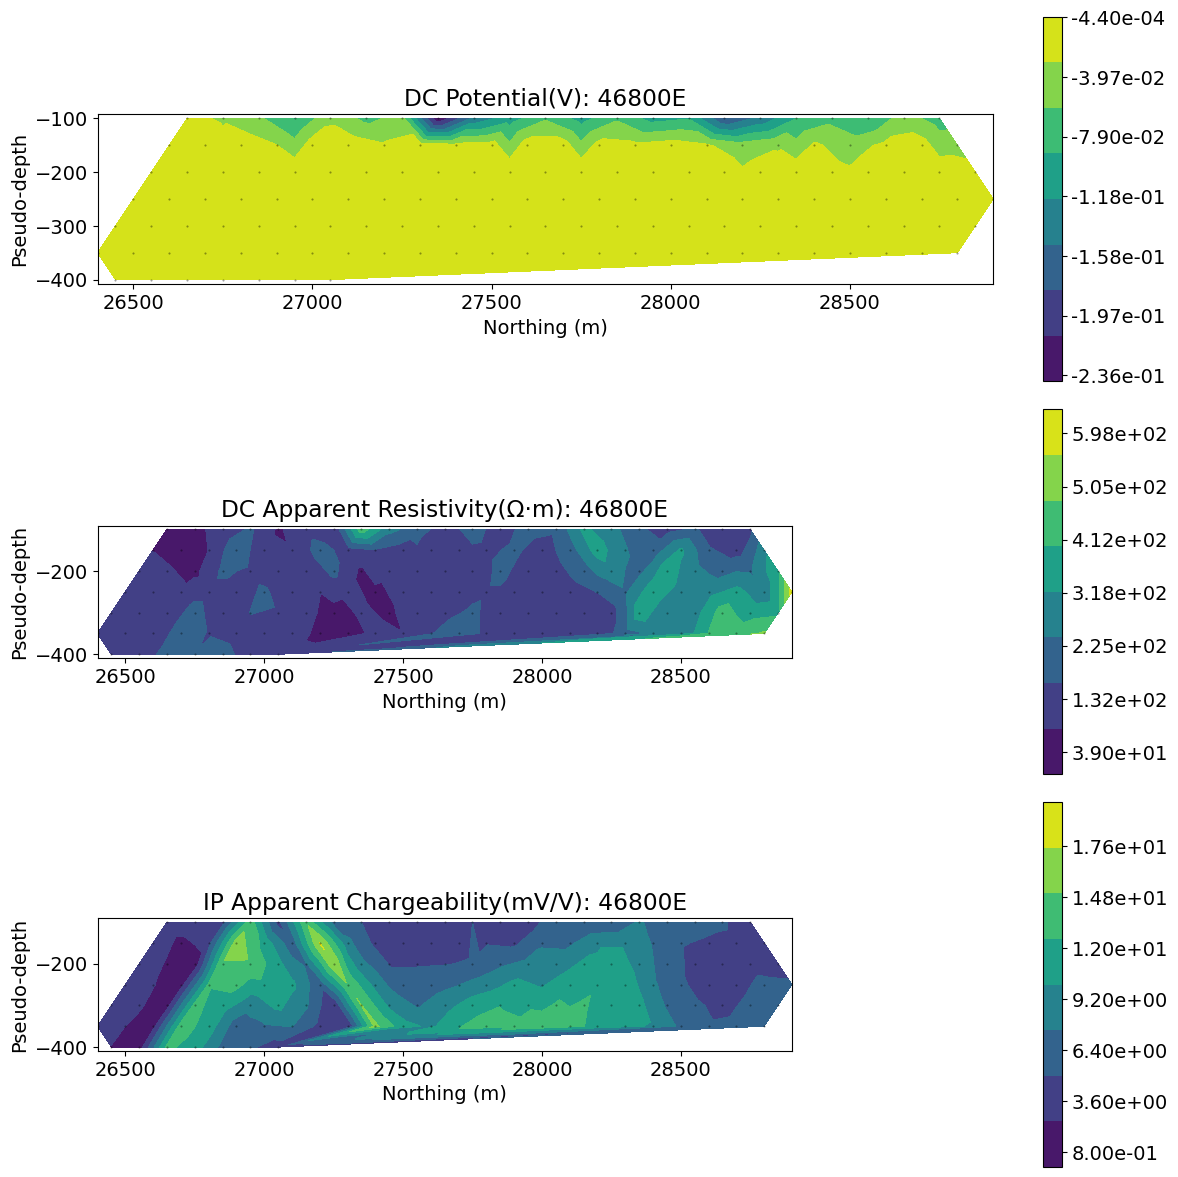

In [ ]:
#Pseudosection plots for DC potential, apparent resistivity and chargeability
fig, ax = plt.subplots(3, 1, figsize=(12, 12))

static_utils.plot_pseudosection(
    dc_data,
    data_type="potential",
    plot_type="contourf",
    data_locations=True,
    ax=ax[0],
    space_type="half-space",
)
ax[0].set_title(f"DC Potential(V): {line}")

static_utils.plot_pseudosection(
    dc_data,
    data_type="apparent resistivity",
    plot_type="contourf",
    data_locations=True,
    ax=ax[1],
    cbar_opts={"pad": 0.25},
    space_type="half-space",
)
ax[1].set_title(f"DC Apparent Resistivity(Ω·m): {line}")

static_utils.plot_pseudosection(
    ip_data,
    data_type="apparent chargeability",
    plot_type="contourf",
    data_locations=True,
    ax=ax[2],
    cbar_opts={"pad": 0.25},
    space_type="half-space",
)
ax[2].set_title(f"IP Apparent Chargeability(mV/V): {line}")

for a in ax:
    a.set_aspect(1.5)
    a.set_xlabel("Northing (m)")
    a.set_ylabel("Pseudo-depth")

plt.tight_layout()

In [ ]:
#Widget shows how the pseudosection is generated
import io
from IPython.display import display

for widget_name in ("source_widget", "source_slider", "source_plot"):
    widget = globals().get(widget_name)
    if widget is not None:
        try:
            widget.close()
        except Exception:
            pass

source_slider = ipywidgets.IntSlider(
    min=0,
    max=int(dc_data_dict["n_sources"]) - 1,
    value=0,
    description="source_ind",
    continuous_update=False,
    style={"description_width": "initial"},
)

source_plot = ipywidgets.Image(format="png")

def _update_source_plot(change=None):
    plt.close("all")
    with plt.ioff():
        plot_building_pseudosection(
            dc_data=dc_data,
            dc_data_dict=dc_data_dict,
            source_ind=source_slider.value,
            xlim=[25900, 29300],
        )
        fig = plt.gcf()

    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight", dpi=150)
    source_plot.value = buffer.getvalue()
    buffer.close()
    plt.close(fig)

source_slider.observe(_update_source_plot, names="value")
_update_source_plot()

source_widget = ipywidgets.VBox([source_slider, source_plot])
display(source_widget)

### Task 1: Display other survey line's dataset using the support of AI

Prompt example: Utilize the existing functionality defined within the notebook to reproduce the pseudosection visualization task for the dataset, specifically targeting the line identified as 47000E. Ensure that the implementation follows the same methodology and parameters used in the original notebook. For every line of code written, include a detailed inline comment that explains its purpose, the data it processes, and its role in generating the pseudosection. Once the pseudosection is successfully displayed for the 47000E line, terminate the script immediately—do not proceed to any additional analysis, plotting, or output.

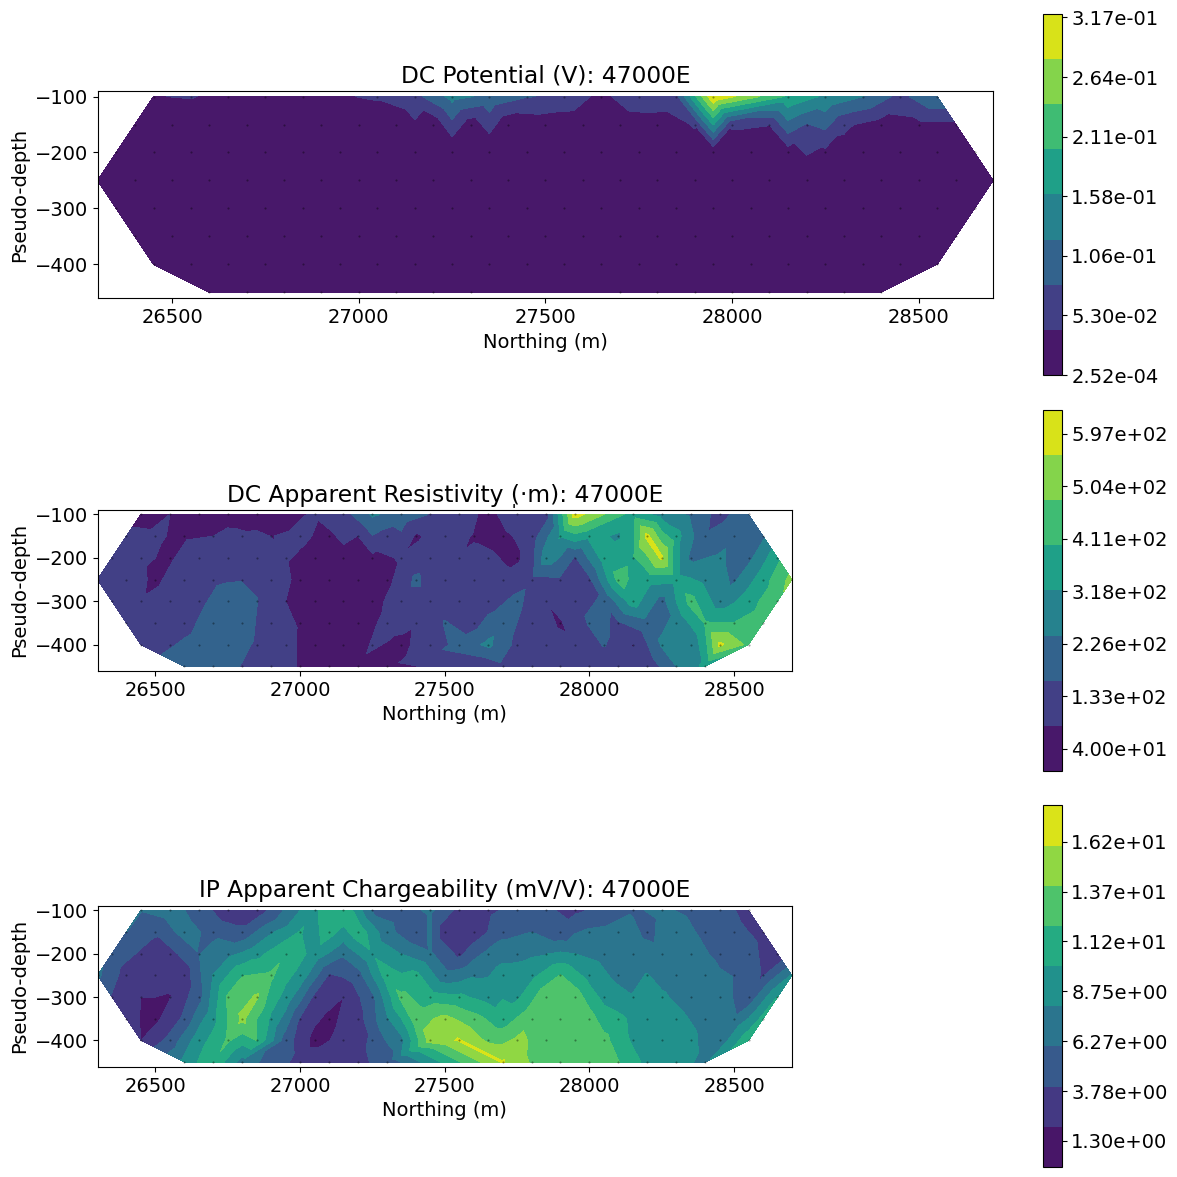

In [ ]:
# Define the specific survey line to be processed
line_47000 = "47000E"

# Construct file paths for the DC potential and IP chargeability observation files for line 47000E
dc_data_file_47000 = f"./century/{line_47000}/{line_47000[:-1]}POT.OBS"
ip_data_file_47000 = f"./century/{line_47000}/{line_47000[:-1]}IP.OBS"

# Parse the DC and IP data files into dictionaries containing electrode locations and observed values
dc_dict_47000 = read_dcip_data(dc_data_file_47000, verbose=False)
ip_dict_47000 = read_dcip_data(ip_data_file_47000, verbose=False)

# Build a SimPEG DC survey object using the dipole-dipole geometry from the data dictionary
survey_dc_47000 = build_dipole_survey(dc_dict_47000, dc, x_shift=0.0)

# Encapsulate the DC survey and observed data (voltages and standard deviations) into a SimPEG Data object
dc_data_obj_47000 = Data(
    survey=survey_dc_47000,
    dobs=np.hstack(dc_dict_47000["observed_data"]),
    standard_deviation=np.hstack(dc_dict_47000["standard_deviations"]),
)

# Build a SimPEG IP survey object specifically for apparent chargeability data
survey_ip_47000 = build_dipole_survey(
    ip_dict_47000, ip, data_type="apparent_chargeability", x_shift=0.0
)

# Encapsulate the IP survey and observed chargeability data into a SimPEG Data object
ip_data_obj_47000 = Data(
    survey=survey_ip_47000,
    dobs=np.hstack(ip_dict_47000["observed_data"]),
    standard_deviation=np.hstack(ip_dict_47000["standard_deviations"]),
)

# Initialize a figure with three subplots to display different physical properties in pseudosection format
fig, ax = plt.subplots(3, 1, figsize=(12, 12))

# Plot the DC Potential pseudosection on the first axis using a half-space projection for depth estimation
static_utils.plot_pseudosection(
    dc_data_obj_47000,
    data_type="potential",
    plot_type="contourf",
    data_locations=True,
    ax=ax[0],
    space_type="half-space",
)
ax[0].set_title(f"DC Potential (V): {line_47000}")

# Plot the DC Apparent Resistivity pseudosection on the second axis to visualize subsurface resistance
static_utils.plot_pseudosection(
    dc_data_obj_47000,
    data_type="apparent resistivity",
    plot_type="contourf",
    data_locations=True,
    ax=ax[1],
    cbar_opts={"pad": 0.25},
    space_type="half-space",
)
ax[1].set_title(f"DC Apparent Resistivity (̩·m): {line_47000}")

# Plot the IP Apparent Chargeability pseudosection on the third axis to visualize polarization effects
static_utils.plot_pseudosection(
    ip_data_obj_47000,
    data_type="apparent chargeability",
    plot_type="contourf",
    data_locations=True,
    ax=ax[2],
    cbar_opts={"pad": 0.25},
    space_type="half-space",
)
ax[2].set_title(f"IP Apparent Chargeability (mV/V): {line_47000}")

# Apply consistent formatting to all axes including labels and aspect ratios for better interpretability
for a in ax:
    a.set_aspect(1.5)
    a.set_xlabel("Northing (m)")
    a.set_ylabel("Pseudo-depth")

# Adjust the layout to prevent overlapping elements and display the finalized plots
plt.tight_layout()
plt.show()

## 2. DC Forward Modeling on a Synthetic Example

Using the same 46800E geometry in local coordinates, in this section we design a synthetic model to generate DC dataset and evaluate the impact of mesh design on the numerical accuracy.  


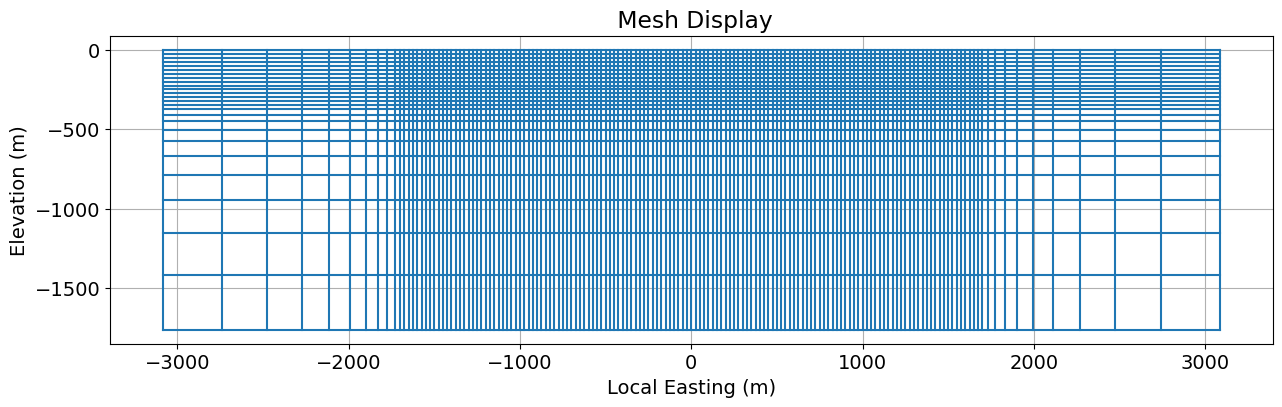

In [ ]:
# Calculate local center and shift coordinates
x_local = 0.5 * (
    np.min(dc_data_dict["a_locations"]) + np.max(np.hstack(dc_data_dict["n_locations"]))
)
survey_synth = build_dipole_survey(dc_data_dict, dc, x_shift=x_local)

# Build the mesh based on the survey geometry
mesh, core_domain_x, core_domain_z = build_mesh(survey_synth)

# Create a wide figure and stretch the mesh display horizontally
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
mesh.plot_grid(ax=ax)
ax.set_title(" Mesh Display")
ax.set_xlabel("Local Easting (m)")
ax.set_ylabel("Elevation (m)")
plt.show()

## 2.1 Half-sapce Model Test
Firstly, by using a half-space model, meaning a constant resistivity value assigned to the mesh, we demonstrate the numerical accuracy can be affected by multiple meshing factors.

In [ ]:
import io
from IPython.display import display

for widget_name in (
    "mesh_design_widget",
    "mesh_design_plot",
    "mesh_slider_nx",
    "mesh_slider_nz",
    "mesh_slider_core_x",
    "mesh_slider_core_z",
    "mesh_slider_ratio",
    "mesh_slider_padding",
    "mesh_slider_pad_x",
    "mesh_slider_pad_z",
    "mesh_slider_rho",
):
    widget = globals().get(widget_name)
    if widget is not None:
        try:
            widget.close()
        except Exception:
            pass

slider_style = {"description_width": "initial"}
slider_layout = ipywidgets.Layout(width="340px")

mesh_slider_nx = ipywidgets.IntSlider(
    description="Cells per 100 m in x",
    min=1,
    max=10,
    value=4,
    continuous_update=False,
    style=slider_style,
    layout=slider_layout,
    readout=True,
)
mesh_slider_nz = ipywidgets.IntSlider(
    description="Cells per 100 m in z",
    min=1,
    max=10,
    value=4,
    continuous_update=False,
    style=slider_style,
    layout=slider_layout,
    readout=True,
)
mesh_slider_core_x = ipywidgets.IntSlider(
    description="Extra core cells on x sides",
    min=0,
    max=10,
    value=4,
    continuous_update=False,
    style=slider_style,
    layout=slider_layout,
    readout=True,
)
mesh_slider_core_z = ipywidgets.IntSlider(
    description="Extra core cells in depth",
    min=0,
    max=10,
    value=4,
    continuous_update=False,
    style=slider_style,
    layout=slider_layout,
    readout=True,
)
mesh_slider_ratio = ipywidgets.FloatSlider(
    description="Core depth as fraction of max AB-MN",
    min=0.1,
    max=1.0,
    value=0.3,
    step=0.01,
    continuous_update=False,
    style=slider_style,
    layout=slider_layout,
    readout=True,
)
mesh_slider_pad_x = ipywidgets.IntSlider(
    description="Number of padding cells in x",
    min=1,
    max=10,
    value=7,
    continuous_update=False,
    style=slider_style,
    layout=slider_layout,
    readout=True,
)
mesh_slider_pad_z = ipywidgets.IntSlider(
    description="Number of padding cells in z",
    min=1,
    max=12,
    value=10,
    continuous_update=False,
    style=slider_style,
    layout=slider_layout,
    readout=True,
)
mesh_slider_rho = ipywidgets.FloatSlider(
    description="log10 of half-space resistivity",
    min=-1.0,
    max=7.0,
    value=2.0,
    step=0.1,
    continuous_update=False,
    style=slider_style,
    layout=slider_layout,
    readout=True,
)

mesh_design_plot = ipywidgets.Image(format="png")

def _update_mesh_design_plot(change=None):
    plt.close("all")
    with plt.ioff():
        mesh_design_simulator(
            survey=survey_synth,
            line_name=line,
            n_cells_per_spacing_x=mesh_slider_nx.value,
            n_cells_per_spacing_z=mesh_slider_nz.value,
            n_core_extra_x=mesh_slider_core_x.value,
            n_core_extra_z=mesh_slider_core_z.value,
            core_domain_z_ratio=mesh_slider_ratio.value,
            n_pad_x=mesh_slider_pad_x.value,
            n_pad_z=mesh_slider_pad_z.value,
            log10_halfspace_resistivity=mesh_slider_rho.value,
        )
        fig = plt.gcf()

    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight", dpi=150)
    mesh_design_plot.value = buffer.getvalue()
    buffer.close()
    plt.close(fig)

for control in (
    mesh_slider_nx,
    mesh_slider_nz,
    mesh_slider_core_x,
    mesh_slider_core_z,
    mesh_slider_ratio,
    mesh_slider_pad_x,
    mesh_slider_pad_z,
    mesh_slider_rho,
):
    control.observe(_update_mesh_design_plot, names="value")

_update_mesh_design_plot()

mesh_design_controls_left = ipywidgets.VBox([
    mesh_slider_nx,
    mesh_slider_nz,
    mesh_slider_core_x,
    mesh_slider_core_z,
])
mesh_design_controls_right = ipywidgets.VBox([
    mesh_slider_ratio,
    mesh_slider_pad_x,
    mesh_slider_pad_z,
    mesh_slider_rho,
])
mesh_design_controls = ipywidgets.HBox(
    [mesh_design_controls_left, mesh_design_controls_right],
    layout=ipywidgets.Layout(align_items="flex-start", justify_content="space-between"),
)
mesh_design_widget = ipywidgets.VBox([mesh_design_controls, mesh_design_plot])
display(mesh_design_widget)

## 2.2  Simple two block synthetic model case for DC forward modelling

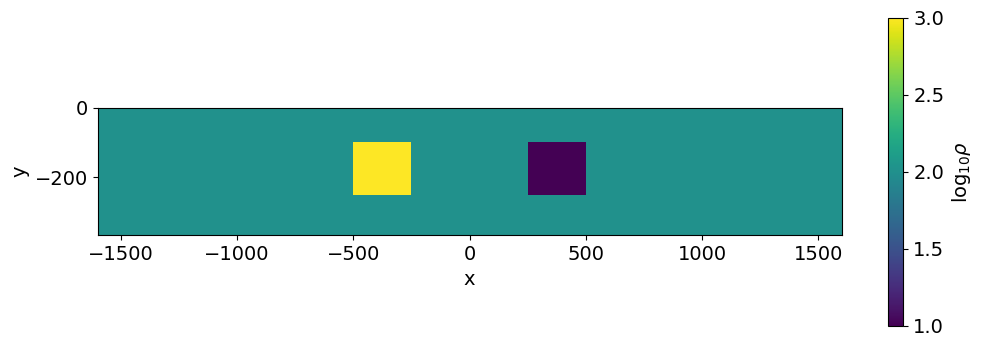

In [ ]:
# Two anaomaly block model built up
rho_background = 100
rho_resistive_block = 1000
rho_conductive_block = 10

xlim_resistive_block = np.r_[-500, -250]
zlim_resistive_block = np.r_[-250, -100]
xlim_conductive_block = np.r_[250, 500]
zlim_conductive_block = np.r_[-250, -100]

rho = rho_background * np.ones(mesh.nC)
inds_resistive_block = (
    (mesh.gridCC[:, 0] >= xlim_resistive_block.min())
    & (mesh.gridCC[:, 0] <= xlim_resistive_block.max())
    & (mesh.gridCC[:, 1] >= zlim_resistive_block.min())
    & (mesh.gridCC[:, 1] <= zlim_resistive_block.max())
)
inds_conductive_block = (
    (mesh.gridCC[:, 0] >= xlim_conductive_block.min())
    & (mesh.gridCC[:, 0] <= xlim_conductive_block.max())
    & (mesh.gridCC[:, 1] >= zlim_conductive_block.min())
    & (mesh.gridCC[:, 1] <= zlim_conductive_block.max())
)
rho[inds_resistive_block] = rho_resistive_block
rho[inds_conductive_block] = rho_conductive_block

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
out = mesh.plot_image(np.log10(rho), ax=ax)
plt.colorbar(out[0], ax=ax, label="log$_{10} \\rho$")
ax.set_xlim(core_domain_x)
ax.set_ylim(core_domain_z + np.r_[-100, 0])
ax.set_aspect(1.5)

Run the DC forward modelling and plot the comparision (background half-spacce model of 100 ohm.m vs two blocks model)

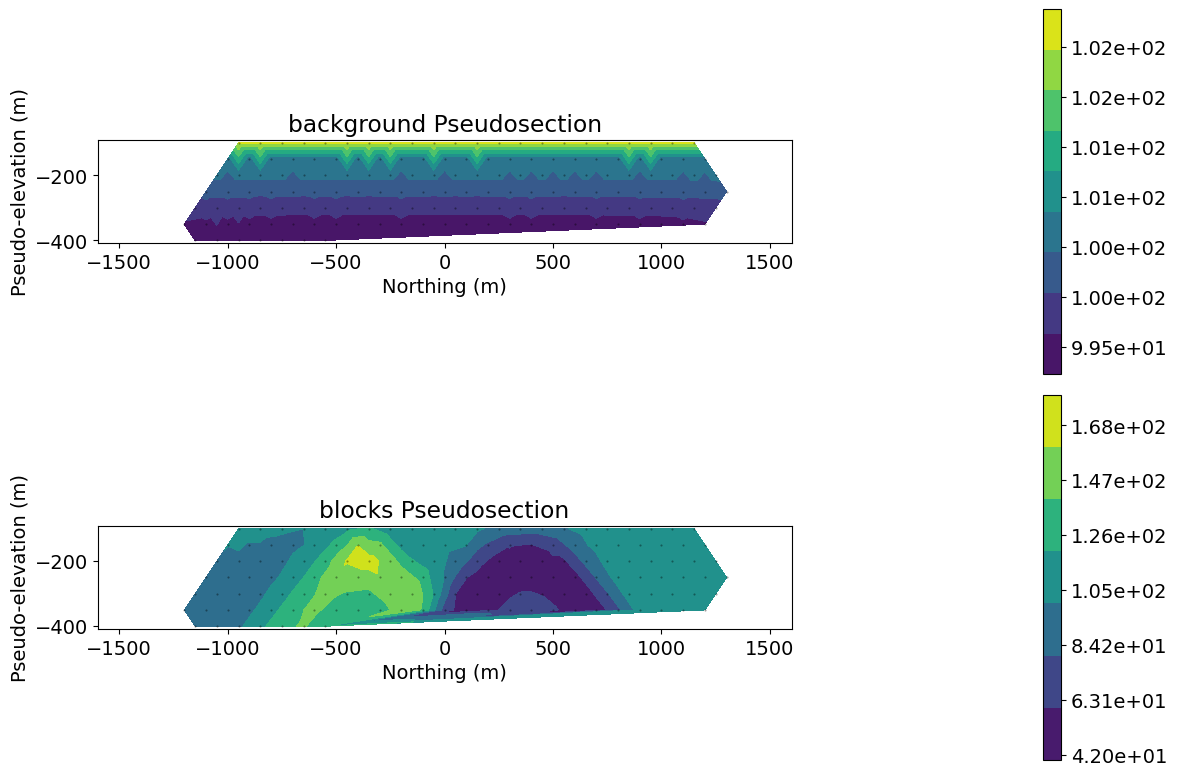

In [ ]:
mapping_identity = maps.IdentityMap(mesh)
simulation_forward = dc.Simulation2DNodal(
    mesh, rhoMap=mapping_identity, solver=Solver, survey=survey_synth
)

model_background = rho_background * np.ones(mesh.nC)
fields_background = simulation_forward.fields(model_background)
synthetic_data_background = simulation_forward.make_synthetic_data(
    model_background, f=fields_background
)

fields = simulation_forward.fields(rho)
synthetic_data = simulation_forward.make_synthetic_data(rho, f=fields)

fig, ax = plt.subplots(2, 1, figsize=(12, 8))
for a, plot_data, title in zip(ax, [synthetic_data_background, synthetic_data], ["background", "blocks"]):
    static_utils.plot_pseudosection(
        plot_data,
        data_type="apparent resistivity",
        plot_type="contourf",
        data_locations=True,
        ax=a,
        contourf_opts={},
        cbar_opts={"pad": 0.25},
    )
    a.set_title(f"{title} Pseudosection")
    a.set_xlim(core_domain_x)
    a.set_aspect(1.5)
    a.set_xlabel("Northing (m)")
plt.tight_layout()

## 3. Inversion

This section contains:
- Synthetic inversion example


## Recall: inversion as optimization

We formulate the inverse problem as an optimization problem consisting of a data misfit and a regularization

$$
\min_{\mathbf{m}} \Phi(\mathbf{m}) = \Phi_d(\mathbf{m}) + \beta\Phi_m(\mathbf{m}) \\ s.t. ~ \Phi_d \leq \Phi_d^* \quad \mathbf{m}_i^{\rm L} \leq \mathbf{m}_ \leq \mathbf{m}_i^{\rm U}
$$

where:
- $\mathbf{m}$ is our inversion model - a vector containing the set of parameters that we invert for


- $\Phi_d$ is the data misfit
  $$
  \Phi_d(\mathbf{m}) = \frac{1}{2}\|\mathbf{W_d} (\mathcal{F}(\mathbf{m}) -    \mathbf{d}^{\text{obs}})\|^2
  $$
  

- $\Phi_m$ is the regularization
  $$
  \Phi_m(\mathbf{m}) = \frac{1}{2}\big(\alpha_s\|\mathbf{W_s} (\mathbf{m} - \mathbf{m}_{\text{ref}})\|^2 + \alpha_x\|\mathbf{W_x} (\mathbf{m})\|^2 + \alpha_z\|\mathbf{W_z} (\mathbf{m})\|^2 \big)
  $$
  

- $\beta$ is a trade-off parameter that weights the relative importance of the data misfit and regularization terms


- $\Phi_d^*$ is our target misfit, which is typically set to $N/2$ where $N$ is the number of data (Parker, 1994) (or also see [Oldenburg & Li (2005)](https://www.researchgate.net/profile/Douglas_Oldenburg/publication/238708196_5_Inversion_for_Applied_Geophysics_A_Tutorial/links/004635282572529927000000.pdf))


### 3.1 Resistivity Synthetic Inversion (Widget)

In [ ]:
# Two block synthetic inversion

model_true = np.log(rho) # Convert the true resistivity model to log-space
mapping_exp = maps.ExpMap(mesh) # Define an exponential mapping to ensure resistivity remains positive

# Set up the 2D DC resistivity simulation with the mapping and solver
simulation_synth_inv = dc.Simulation2DNodal(
    mesh, rhoMap=mapping_exp, solver=Solver, survey=survey_synth, storeJ=True
)

# Generate synthetic data with added Gaussian noise, prepared as input for inversion
synthetic_data_inv = simulation_synth_inv.make_synthetic_data(model_true, add_noise=True)

relative_error = 0.05 # Define a 5% relative error for the data misfit
noise_floor = 1e-4 # Set a noise floor for the data misfit

# Construct the inverse problem object including data misfit and regularization terms
inv_prob_synth = create_inverse_problem(
    synthetic_data=synthetic_data_inv,
    simulation_dc=simulation_synth_inv,
    mesh=mesh,
    rho_background=rho_background,
    relative_error=relative_error,
    noise_floor=noise_floor,
    alpha_s=1e-3,
    alpha_x=1.0,
    alpha_z=1.0,
    maxIter=20,
    maxIterCG=20,
)

# Create the inversion object with directives for beta estimation and cooling
inv_synth, target_misfit_synth, inversion_log_synth = create_inversion(
    inv_prob_synth,
    beta0_ratio=1e2,
    cool_beta=True,
    beta_cooling_factor=2,
    beta_cooling_rate=1,
    use_target=False,
    chi_factor=1,
)

# Initialize the starting model as logrithm
m0_synth = np.log(rho_background) * np.ones(mesh.nC)

# Run the inversion to recover the model
model_recovered_synth = inv_synth.run(m0_synth)

# Extract results from the inversion progress tracker
inversion_results_synth = inversion_log_synth.inversion_results

# Calculate the target data misfit based on the number of data points
phi_d_star_synth = survey_synth.nD / 2


INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.

INFO:SimPEG:
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.2
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  3.52e+02  3.61e+03  0.00e+00  3.61e+03                                 
   1  3.52e+02  2.63e+03  1.22e+00  3.06e+03    9.67e+02      0              
   2  1.76e+02  2.17e+03  3.17e+00  2.73e+03    3.35e+02      0   Skip BFGS  
   3  8.80e+01  1.68e+03  7.32e+00  2.32e+03    2.76e+02      0   Skip BFGS  
   4  4.40e+01  1.21e+03  1.51e+01  1.88e+03    2.12e+02      0   Skip BFGS  
   5  2.20e+01  8.05e+02  2.84e+01  1.43e+03    1.54e+02      0   Skip BFGS  
   6  1.10e+01  4.83e+02  4.90e+01  1.02e+03    1.07e+02      0   Skip BFGS  
   7  5.50e+00  2.74e+02  7.55e+01  6.89e+02    7.24e+01      0   Skip BFGS  
   8  2.75e+00  1.60e+02  1.05e+02  4.47e+02    4.54e+01      0   Skip BFGS  
   9  1.37e+00  9.72e+01

In [ ]:
#Inversion iterations widget
import io
from IPython.display import display

for widget_name in (
    "inversion_results_app",
    "inversion_results_widget",
    "inversion_results_plot",
    "iteration_slider",
):
    widget = globals().get(widget_name)
    if widget is not None:
        try:
            widget.close()
        except Exception:
            pass

iteration_slider = ipywidgets.IntSlider(
    min=0,
    max=len(inversion_results_synth["iteration"]) - 1,
    value=0,
    description="Iteration",
    continuous_update=False,
    style={"description_width": "initial"},
)

inversion_results_plot = ipywidgets.Image(format="png")

def _update_inversion_results_plot(change=None):
    plt.close("all")
    with plt.ioff():
        fig = plt.figure(figsize=(12, 8))
        spec = gridspec.GridSpec(ncols=6, nrows=2, figure=fig)

        ax_tikhonov = fig.add_subplot(spec[:, :2])
        ax_misfit = fig.add_subplot(spec[0, 2:])
        ax_model = fig.add_subplot(spec[1, 2:])

        iteration = iteration_slider.value

        plot_tikhonov_curve(
            inversion_results_synth, phi_d_star=phi_d_star_synth, ax=ax_tikhonov
        )
        ax_tikhonov.plot(
            inversion_results_synth["phi_m"][iteration],
            inversion_results_synth["phi_d"][iteration],
            "ks",
            ms=10,
        )
        ax_tikhonov.set_title(f"iteration {iteration}")

        plot_normalized_misfit(
            inversion_results_synth,
            observed_data=synthetic_data_inv,
            iteration=iteration,
            ax=ax_misfit,
        )

        clim = np.exp(np.r_[model_true.min(), model_true.max()])
        plot_model(
            mesh=mesh,
            mapping=mapping_exp,
            model=inversion_results_synth["model"][iteration],
            core_domain_x=core_domain_x,
            clim=clim,
            ax=ax_model,
        )

        ax_tikhonov.set_aspect(1.0 / ax_tikhonov.get_data_ratio())
        plt.tight_layout()

    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight", dpi=150)
    inversion_results_plot.value = buffer.getvalue()
    buffer.close()
    plt.close(fig)

iteration_slider.observe(_update_inversion_results_plot, names="value")
_update_inversion_results_plot()

inversion_results_widget = ipywidgets.VBox([iteration_slider, inversion_results_plot])
display(inversion_results_widget)

### Task 2: Run IP forward modelling with the same syntehtic model setup with two blocks and generate pseudosection comparison with the half-space model


### A. IP Synthetic Model Setup:

Prompt:only in this cell write the code to Define the chargeability model (eta) using the same block boundaries as the DC resistivity model. Assign a background chargeability of 0 mV/V and specific chargeability values (e.g., 50 mV/V and 100 mV/V) to the blocks. Plot the resulting synthetic chargeability model using the existing mesh.

### B. IP forward modelling with the two blocks synthetic model and visualize the pseudosection against a halfspace zero chargeability model

Prompt: only in this cell, write the code to accompolish that, With the previously ran DC resistivity model setup and the chargeability model setup, run the IP forward modelling and plot the comparision pseudosection of halfspace zero chargeability model against the two block model


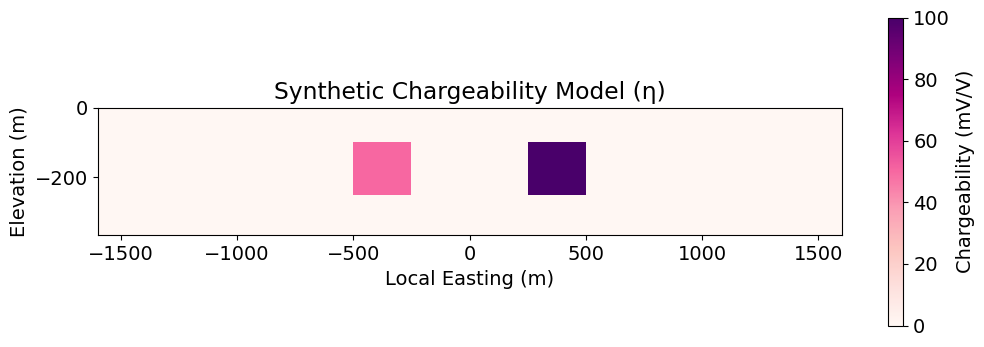

In [ ]:
# Define the chargeability model (eta) using the same block boundaries as the DC model
# Background chargeability is 0 mV/V
eta = np.zeros(mesh.nC)

# Assign specific chargeability values to the blocks identified in the DC setup
# Block 1 (previously resistive) is assigned 50 mV/V
# Block 2 (previously conductive) is assigned 100 mV/V
eta[inds_resistive_block] = 50.0
eta[inds_conductive_block] = 100.0

# Plot the synthetic chargeability model
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
out = mesh.plot_image(eta, ax=ax, pcolor_opts={"cmap": "RdPu"})
plt.colorbar(out[0], ax=ax, label="Chargeability (mV/V)")

# Set display limits and labels consistent with previous plots
ax.set_xlim(core_domain_x)
ax.set_ylim(core_domain_z + np.r_[-100, 0])
ax.set_aspect(1.5)
ax.set_title("Synthetic Chargeability Model (η)")
ax.set_xlabel("Local Easting (m)")
ax.set_ylabel("Elevation (m)")

plt.show()

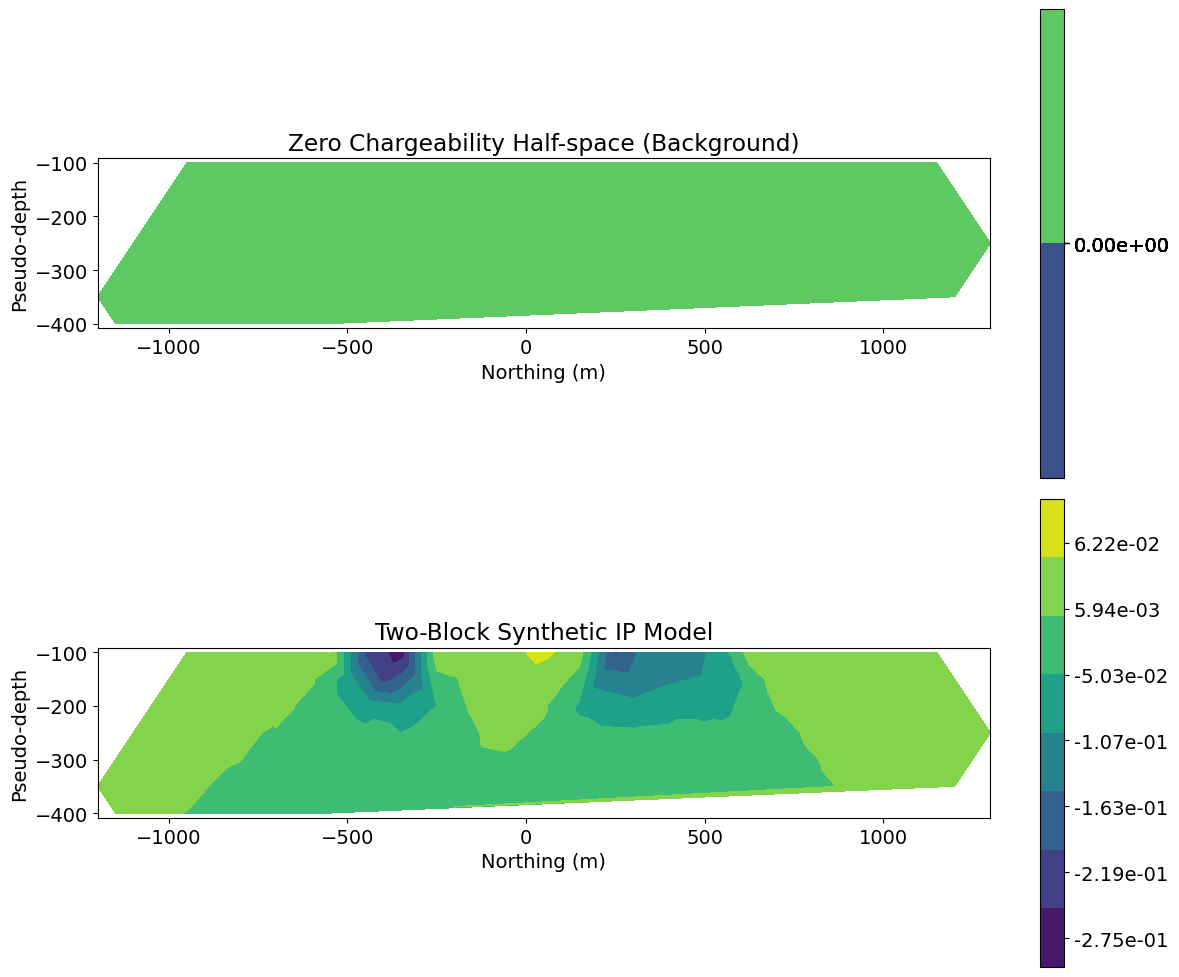

In [ ]:
# Map for chargeability to ensure it stays consistent with mesh cells
mapping_ip = maps.IdentityMap(mesh)

# Create IP simulation using the previously recovered resistivity model
# We use the 'rho' or recovered model from the DC step as the background conductivity
simulation_ip = ip.Simulation2DNodal(
    mesh,
    etaMap=mapping_ip,
    rho=mapping_exp * model_recovered_synth,
    solver=Solver,
    survey=survey_synth
)

# Forward simulate the background model (half-space with 0 mV/V chargeability)
eta_background = np.zeros(mesh.nC)
dpred_ip_background = simulation_ip.make_synthetic_data(eta_background)

# Forward simulate the two-block synthetic chargeability model (defined as 'eta' previously)
dpred_ip_blocks = simulation_ip.make_synthetic_data(eta)

# Plotting the comparison
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Plot background pseudosection
static_utils.plot_pseudosection(
    dpred_ip_background,
    data_type="apparent chargeability",
    plot_type="contourf",
    ax=ax[0],
    cbar_opts={"label": "Apparent Chargeability (mV/V)"}
)
ax[0].set_title("Zero Chargeability Half-space (Background)")

# Plot two-block model pseudosection
static_utils.plot_pseudosection(
    dpred_ip_blocks,
    data_type="apparent chargeability",
    plot_type="contourf",
    ax=ax[1],
    cbar_opts={"label": "Apparent Chargeability (mV/V)"}
)
ax[1].set_title("Two-Block Synthetic IP Model")

# Clean up axes
for a in ax:
    a.set_aspect(1.5)
    a.set_xlabel("Northing (m)")
    a.set_ylabel("Pseudo-depth")

plt.tight_layout()
plt.show()

### C. Chargeability Synthetic Inversion (Widget)

Task 3: Using the same synthetic two block IP model setup to construct and run a chTaskargeability synthetic inversion

prompt: according to the previous run IP synthetic forward modelling and the DC inversion code, write script that construct the IP inversion scheme and run the chargeability inversion with the same iterations widget display as the DC inversion, the same inversion setting as the DC inversion


use existing variables and helper functions.
In this cell, build and run the IP inversion for the two-block chargeability model, then show an interactive results view similar to the DC inversion widget.

What to do:

Create the local IP survey from the existing IP data.
Build the IP simulation using the current resistivity model and chargeability mapping.
Make noisy synthetic IP data from the existing true chargeability model.
Run inversion with the same settings used in the DC inversion:

starting model is all zeros
Save inversion results for plotting.
Build an interactive slider view with 3 panels:
left: inversion progress curve
top-right: data-fit pseudosection (predicted vs observed difference)
bottom-right: recovered chargeability section
Use a red-blue color map for recovered chargeability, centered around zero, and label colorbar as Chargeability (V/V).
If this cell is rerun, close previous widget objects first.
Display the slider + figure widget at the end.

In [ ]:
import io
from IPython.display import display

# 1. Setup IP Survey and Simulation
# Build a synthetic survey using the original field IP data geometry shifted to local coordinates
survey_ip_synth = build_dipole_survey(ip_data_dict, ip, data_type="apparent_chargeability", x_shift=x_local)

# simulation_ip was defined in the previous cell, but we'll ensure it's configured for the inversion
simulation_ip_inv = ip.Simulation2DNodal(
    mesh,
    etaMap=maps.IdentityMap(mesh),
    rho=mapping_exp * model_recovered_synth,
    solver=Solver,
    survey=survey_ip_synth,
    storeJ=True
)

# 2. Create Noisy Synthetic IP Data
# Use the previously defined 'eta' (the two-block model) as the true model
synthetic_ip_data_inv = simulation_ip_inv.make_synthetic_data(eta, add_noise=True, relative_error=0.05, noise_floor=1e-4)

# 3. Setup and Run Inversion
inv_prob_ip = create_inverse_problem(
    synthetic_data=synthetic_ip_data_inv,
    simulation_dc=simulation_ip_inv, # helper uses name simulation_dc but works for IP
    mesh=mesh,
    rho_background=0.0, # reference model for chargeability is 0
    relative_error=0.05,
    noise_floor=1e-4,
    alpha_s=1e-3,
    alpha_x=1.0,
    alpha_z=1.0,
    mref=np.zeros(mesh.nC), # Reference model for eta is 0
    maxIter=100
)

# Create inversion with directives
inv_ip, target_ip, log_ip = create_inversion(
    inv_prob_ip,
    beta0_ratio=1e1,
    use_target=False
)

# Starting model is all zeros
m0_ip = np.zeros(mesh.nC)
model_recovered_ip = inv_ip.run(m0_ip)
results_ip = log_ip.inversion_results
phi_d_star_ip = survey_ip_synth.nD / 2

# 4. Interactive Visualization Widget
for w in ['ip_iter_slider', 'ip_results_plot', 'ip_widget']:
    if w in locals(): globals()[w].close()

ip_iter_slider = ipywidgets.IntSlider(min=0, max=len(results_ip['iteration'])-1, value=len(results_ip['iteration'])-1, description='Iteration')
ip_results_plot = ipywidgets.Image(format='png')

def update_ip_plot(change=None):
    plt.close('all')
    with plt.ioff():
        fig = plt.figure(figsize=(14, 9))
        gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.5])
        ax_tik = fig.add_subplot(gs[:, 0])
        ax_mis = fig.add_subplot(gs[0, 1])
        ax_mod = fig.add_subplot(gs[1, 1])

        it = ip_iter_slider.value
        plot_tikhonov_curve(results_ip, phi_d_star_ip, ax=ax_tik)
        ax_tik.plot(results_ip['phi_m'][it], results_ip['phi_d'][it], 'ks', ms=10)

        plot_normalized_misfit(results_ip, synthetic_ip_data_inv, iteration=it, ax=ax_mis)

        # Recovered model plot
        val = results_ip['model'][it]
        clim_val = np.abs(eta).max()
        out = mesh.plot_image(val, ax=ax_mod, pcolor_opts={'cmap': 'RdBu_r', 'norm': Normalize(vmin=-clim_val, vmax=clim_val)})
        ax_mod.set_xlim(core_domain_x)
        ax_mod.set_ylim(core_domain_z + np.r_[-100, 0])
        ax_mod.set_aspect(1.5)
        plt.colorbar(out[0], ax=ax_mod, label='Chargeability (mV/V)', orientation='horizontal', pad=0.3)
        ax_mod.set_title(f'Recovered IP Model - Iter {it}')

        plt.tight_layout()
        buf = io.BytesIO()
        fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
        ip_results_plot.value = buf.getvalue()

ip_iter_slider.observe(update_ip_plot, names='value')
update_ip_plot()
display(ipywidgets.VBox([ip_iter_slider, ip_results_plot]))

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.

INFO:SimPEG:
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.2
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  6.59e+03  6.04e+04  0.00e+00  6.04e+04                                 
   1  6.59e+03  5.52e+04  2.59e-01  5.69e+04    1.91e+04      0              
   2  3.30e+03  5.31e+04  7.02e-01  5.55e+04    3.87e+03      0   Skip BFGS  
   3  1.65e+03  5.08e+04  1.71e+00  5.37e+04    2.84e+03      0   Skip BFGS  
   4  8.24e+02  4.83e+04  3.94e+00  5.15e+04    2.22e+03      0   Skip BFGS  
   5  4.12e+02  4.56e+04  8.58e+00  4.92e+04    1.70e+03      0   Skip BFGS  
   6  2.06e+02  4.29e+04  1.81e+01  4.67e+04    1.26e+03      0   Skip BFGS  
   7  1.03e+02  4.00e+04  3.83e+01  4.40e+04    9.40e+02      0   Skip BFGS  
   8  5.15e+01  3.70e+04  8.17e+01  4.12e+04    6.97e+02      0   Skip BFGS  
   9  2.58e+01  3.35e+04